## Shallow vs. Deep neural networks


<a href="https://colab.research.google.com/github/fahadsultan/csc372/blob/main/dnn_deep.ipynb" target="_blank" align="right">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


### Ability to approximate different functions 

Previously, we argued that shallow neural networks with enough capacity (hidden units) could model any continuous function arbitrarily closely. 

In this chapter, we saw that a deep network with two hidden layers could represent the composition of two shallow networks. 

If the second of these networks computes the identity function, then this deep network replicates a single shallow network. 

Hence, it can also approximate any continuous function arbitrarily closely given suﬀicient capacity.

<br/>

### Number of linear regresions per parameter 

<br/>

A shallow network with one input, one output, and $D > 2$ hidden units can create up to $D+ 1$ linear regions and is defined by $3D+ 1$ parameters. 

A deep network with one input, one output, and $K$ layers of $D>2$ hidden units can create a function with up to $(D+ 1)K$ linear regions using $3D+ 1 + (K−1)D(D+ 1)$ parameters.

<br/>

<img src="assets/Chap04/DeepParams.svg" style="filter: invert(1);" width="100%">

<br/>

The maximum number of linear regions for neural networks increases rapidly with the network depth. 

a) Network with $D_i = 1$ input. Each curve represents a fixed number of hidden layers $K$, as we vary the number of hidden units $D$ per layer. 

    For a fixed parameter budget (horizontal position), deeper networks produce more linear regions than shallower ones. A network with $K = 5$ layers and $D = 10$ hidden units per layer has 471 parameters (highlighted point) and can produce 161,051 regions. 

b) Network with $D_i = 10$ inputs. Each subsequent point along a curve represents ten hidden units. Here, a model with $K = 5$ layers and $D = 50$ hidden units per layer has 10,801 parameters (highlighted point) and can create more than 1040 linear regions.

Figure 4.7a shows how the maximum number of linear regions increases as a function of the number of parameters for networks mapping scalar input x to scalar output y.
Deep neural networks create much more complex functions for a fixed parameter budget.
This effect is magnified as the number of input dimensions Di increases (figure 4.7b),
although computing the maximum number of regions is less straightforward.
This seems attractive, but the flexibility of the functions is still limited by the number
of parameters. Deep networks can create extremely large numbers of linear regions, but
these contain complex dependencies and symmetries. We saw some of these when we
considered deep networks as “folding” the input space (figure 4.3). So, it’s not clear that
the greater number of regions is an advantage unless (i) there are similar symmetries in
the real-world functions that we wish to approximate or (ii) we have reason to believe
that the mapping from input to output really does involve a composition of simpler
functions.

### Depth efficiency

Both deep and shallow networks can model arbitrary functions, but some functions can be approximated much more eﬀiciently with deep networks. 

Functions have been identified that require a shallow network with exponentially more hidden units to achieve an equivalent approximation to that of a deep network. 

This phenomenon is referred to as the depth eﬀiciency of neural networks. This property is also attractive, but it’s not
clear that the real-world functions that we want to approximate fall into this category.

### Large, structured inputs 

We have discussed fully connected networks where every element of each layer contributes
to every element of the subsequent one. However, these are not practical for large, structured inputs like images, where the input might comprise $\sim 10^6$ pixels. The number
of parameters would be prohibitive, and moreover, we want different parts of the image
to be processed similarly; there is no point in independently learning to recognize the
same object at every possible position in the image.
The solution is to process local image regions in parallel and then gradually integrate
information from increasingly large regions. This kind of local-to-global processing is
diﬀicult to specify without using multiple layers (see chapter 10).

### Training and generalization 

A further possible advantage of deep networks over shallow networks is their ease of fitting; it is usually easier to train moderately deep networks than to train shallow ones (see
figure 20.2). It may be that overparameterized deep models (i.e., those with more parameters than training examples) have a large family of roughly equivalent solutions that
are easy to find. 

However, as we add more hidden layers, training becomes more diﬀicult again. 

Many methods have been developed to mitigate this problem (see chapter 11).

Deep neural networks also seem to generalize to new data better than shallow ones. 

In practice, the best results for most tasks have been achieved using networks with tens or hundreds of layers. 

Neither of these phenomena are well understood, and we return
to them in chapter 20

<!-- <img src="assets/Chap04/DeepConcatQuestion.svg" style="filter: invert(1);" width="100%">

Composition of two networks for problem 4.1. a) The output y of the
first network becomes the input to the second. b) The first network computes
this function with output values y ∈ [−1, 1]. c) The second network computes
this function on the input range y ∈ [−1, 1].

<img src="assets/Chap04/DeepProbZeroCross.svg" style="filter: invert(1);" width="100%">

Hidden unit activations for problem 4.8. a) First hidden unit has a
joint at position x = 1/6 and a slope of one in the active region. b) Second hidden
unit has a joint at position x = 2/6 and a slope of one in the active region. c)
Third hidden unit has a joint at position x = 4/6 and a slope of minus one in the
active region.




\begin{eqnarray}\label{eq:dnn_deep_param_calc}
  N_{r} = \left(\frac{D}{D_{i}}+1\right)^{D_{i}(K-1)}\cdot\sum_{j=0}^{D_{i}}\binom{D}{j}.
 \end{eqnarray}


\begin{eqnarray}
 \mbox{ReLU}\Bigl[\boldsymbol\beta_{1}\!+\!\lambda_1\!\cdot\!\boldsymbol\Omega_{1}\mbox{ReLU}\left[\boldsymbol\beta_{0}\!+\!\lambda_{0}\cdot\boldsymbol\Omega_{0}\mathbf{x}\right] \Bigr]\!=\! \lambda_0\lambda_{1}\cdot \mbox{ReLU}\left[\frac{1}{\lambda_0\lambda_1}\boldsymbol\beta_{1}\!+\!\boldsymbol\Omega_{1}\mbox{ReLU}\left[\frac{1}{\lambda_0}\boldsymbol\beta_{0}\!+\!\boldsymbol\Omega_{0}\mathbf{x}\right]\right],
 \end{eqnarray} -->

In [ ]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt
plt.style.use('dark_background')     

# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation
     
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

# # Plot the shallow neural network.  We'll assume input in is range [-1,1] and output [-1,1]
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Input'); ax.set_ylabel('Output')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

Let's define a network. We'll just consider the inputs and outputs over the range [-1,1].

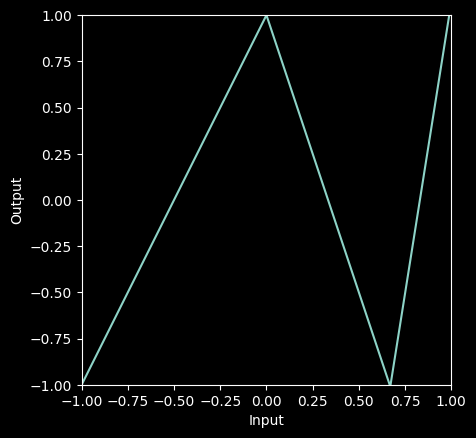

In [9]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define a range of input values
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# We run the neural network for each of these input values
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# And then plot it
plot_neural(n1_in, n1_out)

Now we'll define the same neural network, but this time, we will use matrix form as in equation 4.15. When you get this right, it will draw the same plot as above.

In [ ]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3


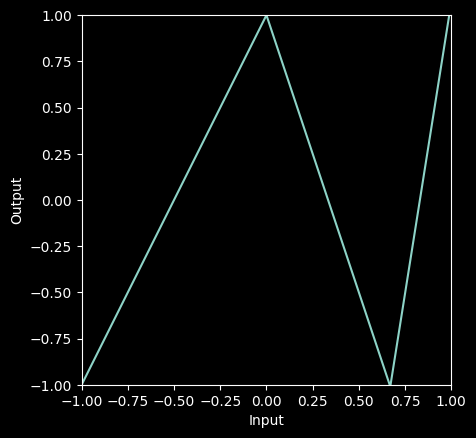

In [ ]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

beta_1[0,0] = n1_phi_0
Omega_1[0,0] = n1_phi_1
Omega_1[0,1] = n1_phi_2
Omega_1[0,2] = n1_phi_3

# Make sure that input data matrix has different inputs in its columns
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in,(n_dim_in,n_data))

# This runs the network for ALL of the inputs, x at once so we can draw graph
h1 = ReLU(beta_0 + np.matmul(Omega_0,n1_in_mat))
n1_out = beta_1 + np.matmul(Omega_1,h1)

# Draw the network and check that it looks the same as the non-matrix case
plot_neural(n1_in, n1_out)

Now we'll feed the output of the first network into the second one.

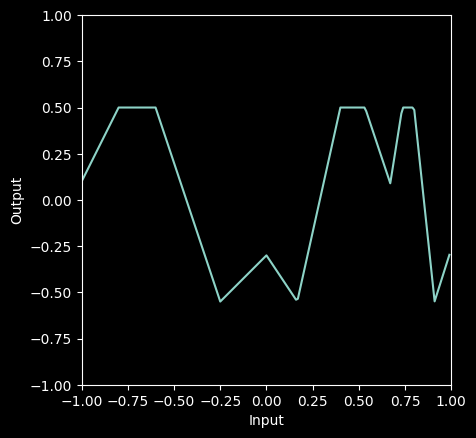

In [12]:
# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define a range of input values
n2_in = np.arange(-1,1,0.01)

# We run the second neural network on the output of the first network
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# And then plot it
plot_neural(n1_in, n2_out)

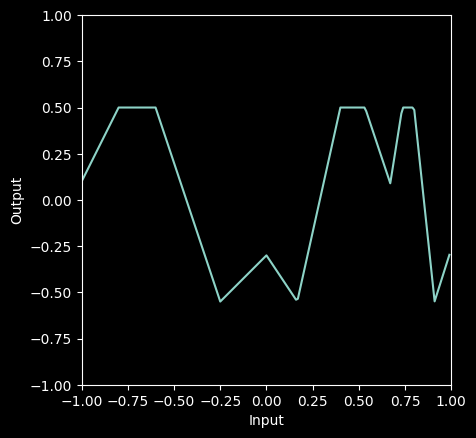

In [17]:
beta_0  = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1  = np.zeros((3,1))
Omega_1 = np.zeros((3,3))
beta_2  = np.zeros((1,1))
Omega_2 = np.zeros((1,3))

beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

beta_1[0,0] = n2_theta_10 + n2_theta_11 * n1_phi_0
beta_1[1,0] = n2_theta_20 + n2_theta_21 * n1_phi_0
beta_1[2,0] = n2_theta_30 + n2_theta_31 * n1_phi_0

Omega_1[0,0] = n2_theta_11 * n1_phi_1
Omega_1[0,1] = n2_theta_11 * n1_phi_2
Omega_1[0,2] = n2_theta_11 * n1_phi_3

Omega_1[1,0] = n2_theta_21 * n1_phi_1
Omega_1[1,1] = n2_theta_21 * n1_phi_2
Omega_1[1,2] = n2_theta_21 * n1_phi_3

Omega_1[2,0] = n2_theta_31 * n1_phi_1
Omega_1[2,1] = n2_theta_31 * n1_phi_2
Omega_1[2,2] = n2_theta_31 * n1_phi_3

beta_2[0,0]  = n2_phi_0
Omega_2[0,0] = n2_phi_1
Omega_2[0,1] = n2_phi_2
Omega_2[0,2] = n2_phi_3

# Make sure that input data matrix has different inputs in its columns
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in,(n_dim_in,n_data))

# This runs the network for ALL of the inputs, x at once so we can draw graph (hence extra np.ones term)
h1 = ReLU(beta_0 + np.matmul(Omega_0,n1_in_mat))
h2 = ReLU(beta_1 + np.matmul(Omega_1,h1))
n1_out = beta_2 + np.matmul(Omega_2,h2)

# Draw the network and check that it looks the same as the non-matrix version
plot_neural(n1_in, n1_out)

Now let's make a deep network with 3 hidden layers. It will have 
 inputs, 
 neurons in the first layer, 
 neurons in the second layer and 
 neurons in the third layer, and 
 output. Consult figure 4.6 and equations 4.15 for guidance.

In [19]:

# define sizes
D_i=4; D_1=5; D_2=2; D_3=4; D_o=1
# We'll choose the inputs and parameters of this network randomly using np.random.normal
# For example, we'll set the input using
n_data = 4;
x = np.random.normal(size=(D_i, n_data))
# TODO initialize the parameters randomly with the correct sizes
# Replace the lines below
beta_0 = np.random.normal(size=(D_1,1))
Omega_0 = np.random.normal(size=(D_1,D_i))
beta_1 = np.random.normal(size=(D_2,1))
Omega_1 = np.random.normal(size=(D_2,D_1))
beta_2 = np.random.normal(size=(D_3,1))
Omega_2 = np.random.normal(size=(D_3,D_2))
beta_3 = np.random.normal(size=(D_o,1))
Omega_3 = np.random.normal(size=(D_o,D_3))


# If you set the parameters to the correct sizes, the following code will run
h1 = ReLU(beta_0 + np.matmul(Omega_0,x));
h2 = ReLU(beta_1 + np.matmul(Omega_1,h1));
h3 = ReLU(beta_2 + np.matmul(Omega_2,h2));
y = beta_3 + np.matmul(Omega_3,h3)

if h1.shape[0] is not D_1 or h1.shape[1] is not n_data:
  print("h1 is wrong shape")
if h2.shape[0] is not D_2 or h1.shape[1] is not n_data:
  print("h2 is wrong shape")
if h3.shape[0] is not D_3 or h1.shape[1] is not n_data:
  print("h3 is wrong shape")
if y.shape[0] is not D_o or h1.shape[1] is not n_data:
  print("Output is wrong shape")

# Print the inputs and outputs
print("Input data points")
print(x)
print ("Output data points")
print(y)

Input data points
[[ 1.0108904  -0.29432015  0.44912502 -0.11798405]
 [ 0.51243358  1.52377265  0.03393024 -0.0446964 ]
 [-0.0107712  -1.4816905   2.22382715 -1.86604414]
 [ 0.80455297  0.35383715  0.04226568  1.3288029 ]]
Output data points
[[1.09784554 0.37590693 0.7721002  0.54342723]]
